# Figure 2 — SBS1 burden (molecular time × diploid-genome–corrected SBS1)

Per-sample SBS1 burden across all cohorts (INFORM, SCANB, PCAWG, GEL), from Table S2.

* **SBS1 MRCA burden** = `scaled_SBS1 × 2 × 3000` (diploid-genome correction), grey dots.
* **HRD / WGD SBS1 burden** = `HRDTime`/`WGDTime` × `SBS1_total`.
* Error bars = 95% CI; shaded blocks = IQR (both scaled by `SBS1_total`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ── Formatting: no top/right spines, thin spines/ticks, embed fonts ──
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "sans-serif", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
})

# ── Global paths ─────────────────────────────────────────────────────
# Reproduce from the published supplement (Table S2, HRDTimer estimates)
V4_PATH = "../supplemental_tables_v2/SupTable8_HRDTimer_estimates.xlsx"
S2_INV = {"sample_id": "sample", "subtype": "type", "is_WGD": "isWGD", "tumour_grade": "grade", "clinical_stage": "final_stage_main", "hrd_origin": "hrd.origin", "hrd_origin_with_methylation": "hrd.origin.with.meth", "HRD_genotype": "genotype", "CHORD_genotype": "chord.genotype", "TP53_mutated": "isTp53Mut", "PALB2_mutated": "isPALB2Mut", "HRDetect_score": "HRDetect", "is_HRD": "HRDetect.isHRD", "T_stage": "T_STAGE", "tumour_size_mm": "tum.size.mm", "age_band_label": "age_band", "BRCA1_monoallelic": "isBRCA1Monoallelic", "BRCA1_biallelic": "isBRCA1Biallelic", "BRCA2_monoallelic": "isBRCA2Monoallelic", "BRCA2_biallelic": "isBRCA2Biallelic", "BRCA1_promoter_methylation_class": "BRCA1_PromMetClass", "RAD51C_promoter_methylation_class": "RAD51C_PromMetClass", "HRDTime_molecular": "HRDTime", "HRDTime_molecular_ci_lo": "HRDTime_ci_lo", "HRDTime_molecular_ci_hi": "HRDTime_ci_hi", "HRDTime_molecular_IQR_lo": "HRDTime_ci_IQR_lo", "HRDTime_molecular_IQR_hi": "HRDTime_ci_IQR_hi", "WGDTime_molecular": "WGDTime", "WGDTime_molecular_ci_lo": "WGDTime_ci_lo", "WGDTime_molecular_ci_hi": "WGDTime_ci_hi", "WGDTime_molecular_IQR_lo": "WGDTime_ci_IQR_lo", "WGDTime_molecular_IQR_hi": "WGDTime_ci_IQR_hi", "HRD_duration_median_yrs": "HRD_Duration_median", "HRD_duration_ci05_yrs": "HRD_Duration_ci05", "HRD_duration_ci95_yrs": "HRD_Duration_ci95", "TS_duration_median_yrs": "TS_Duration_median", "TS_duration_ci05_yrs": "TS_Duration_ci05", "TS_duration_ci95_yrs": "TS_Duration_ci95", "HRD_onset_age_median": "HRD_crossing_age_median", "HRD_onset_age_ci05": "HRD_crossing_age_ci05", "HRD_onset_age_ci95": "HRD_crossing_age_ci95", "TS_onset_age_median": "TS_crossing_age_median", "TS_onset_age_ci05": "TS_crossing_age_ci05", "TS_onset_age_ci95": "TS_crossing_age_ci95"}
OUT_DIR = "../output/Fig2_SBS1_burden"
os.makedirs(OUT_DIR, exist_ok=True)

A4_LANDSCAPE_W = 11.69  # max figure width (A4 landscape, inches)
COHORT_ORDER = ["INFORM", "SCANB", "PCAWG", "GEL"]
HRD_COLOR, WGD_COLOR, IQR_COLOR, MRCA_COLOR = "#3d405b", "#fcad97", "#dbdbdb", "grey"

In [2]:
# ── Build the burden table from v4 ───────────────────────────────────
df = pd.read_excel(V4_PATH, sheet_name="HRDTimer Estimates").rename(columns=S2_INV)

# keep samples with both a molecular-time estimate and a SBS1 exposure
df = df.dropna(subset=["HRDTime", "WGDTime", "scaled_SBS1"]).copy()

# diploid-genome-corrected total SBS1 burden
df["SBS1_total"] = df["scaled_SBS1"] * 2 * 3000

# molecular-time-weighted burdens + scaled CI / IQR half-widths
for tt in ["HRD", "WGD"]:
    T = "HRDTime" if tt == "HRD" else "WGDTime"
    df[f"{tt}_SBS1_burden"] = df[T] * df["SBS1_total"]
    df[f"{tt}_SBS1_ci_lo"]  = df[f"{T}_ci_lo"]     * df["SBS1_total"]
    df[f"{tt}_SBS1_ci_hi"]  = df[f"{T}_ci_hi"]     * df["SBS1_total"]
    df[f"{tt}_SBS1_iqr_lo"] = df[f"{T}_ci_IQR_lo"] * df["SBS1_total"]
    df[f"{tt}_SBS1_iqr_hi"] = df[f"{T}_ci_IQR_hi"] * df["SBS1_total"]

# order: cohort, then ascending HRD SBS1 burden
df["_c"] = df["cohort"].map({c: i for i, c in enumerate(COHORT_ORDER)}).fillna(99)
df = df.sort_values(["_c", "HRD_SBS1_burden"]).drop(columns="_c").reset_index(drop=True)
df["ID_display"] = df["sample"]

# cohort block boundaries + label centres
coh = df["cohort"].tolist()
boundaries = [i for i in range(1, len(coh)) if coh[i] != coh[i-1]]
pos = {}
for i, c in enumerate(coh):
    pos.setdefault(c, []).append(i)
cohort_labels = [(np.mean(p), c) for c, p in pos.items()]

print(f"Samples: {len(df)}")
print(df.groupby("cohort").size().to_string())

Samples: 115
cohort
GEL       56
INFORM     6
PCAWG     20
SCANB     33


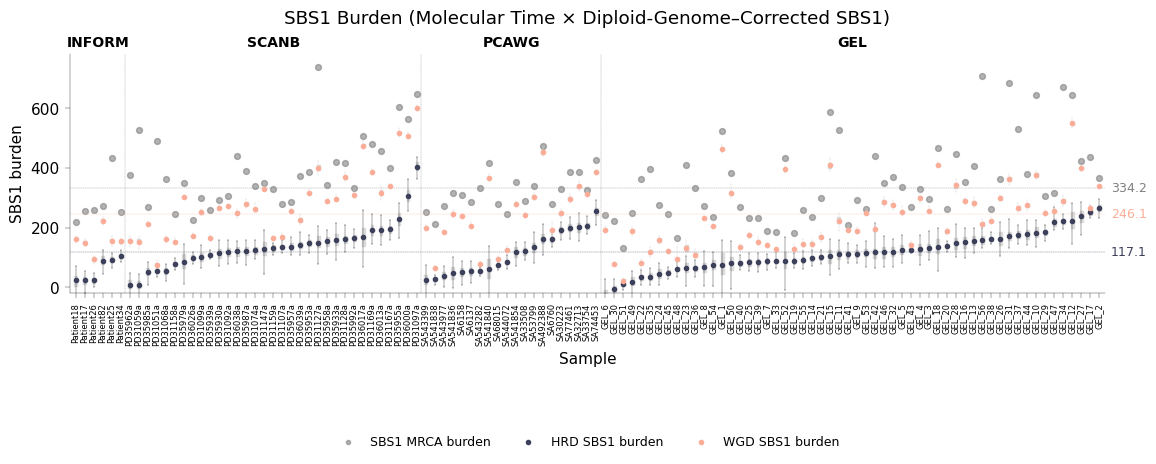

In [3]:
# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(A4_LANDSCAPE_W, 6))
x = df.index

ax.scatter(x, df["SBS1_total"], color=MRCA_COLOR, alpha=0.6, s=18, zorder=0)

for _, r in df.iterrows():
    # HRD
    ax.errorbar(r.name, r["HRD_SBS1_burden"], yerr=[[r["HRD_SBS1_ci_lo"]], [r["HRD_SBS1_ci_hi"]]],
                fmt="o", color=HRD_COLOR, ecolor="k", elinewidth=0.25, capsize=1, capthick=0.25, markersize=3)
    ax.fill_between([r.name - 0.16, r.name + 0.16],
                    r["HRD_SBS1_burden"] - r["HRD_SBS1_iqr_lo"],
                    r["HRD_SBS1_burden"] + r["HRD_SBS1_iqr_hi"], color=IQR_COLOR, zorder=0)
    # WGD
    ax.errorbar(r.name, r["WGD_SBS1_burden"], yerr=[[r["WGD_SBS1_ci_lo"]], [r["WGD_SBS1_ci_hi"]]],
                fmt="o", color=WGD_COLOR, ecolor="lightgrey", elinewidth=0.25, capsize=1, capthick=0.25, markersize=3)
    ax.fill_between([r.name - 0.16, r.name + 0.16],
                    r["WGD_SBS1_burden"] - r["WGD_SBS1_iqr_lo"],
                    r["WGD_SBS1_burden"] + r["WGD_SBS1_iqr_hi"], color=IQR_COLOR, zorder=0)

for b in boundaries:
    ax.axvline(x=b - 0.5, color="grey", linestyle="--", linewidth=0.25)
for mid, c in cohort_labels:
    ax.text(mid, 1.02, c, ha="center", va="bottom", fontsize=10, fontweight="bold",
            transform=ax.get_xaxis_transform())

# median reference lines
for col, color in [("WGD_SBS1_burden", WGD_COLOR), ("HRD_SBS1_burden", HRD_COLOR), ("SBS1_total", MRCA_COLOR)]:
    m = df[col].median()
    ax.axhline(y=m, color=color, linestyle="--", linewidth=0.25)
    ax.text(1.005, m, f"{m:.1f}", transform=ax.get_yaxis_transform(),
            va="center", ha="left", color=color, fontsize=9, clip_on=False)

ax.set_xticks(x)
ax.set_xticklabels(df["ID_display"], rotation=90, fontsize=6)
ax.set_ylabel("SBS1 burden")
ax.set_xlabel("Sample")
ax.set_title("SBS1 Burden (Molecular Time × Diploid-Genome–Corrected SBS1)", pad=22)
ax.set_xlim(-0.7, len(df) - 0.3)
ax.set_ylim(bottom=-20)

handles = [
    plt.Line2D([], [], color=MRCA_COLOR, marker="o", linestyle="None", markersize=3, alpha=0.6, label="SBS1 MRCA burden"),
    plt.Line2D([], [], color=HRD_COLOR, marker="o", linestyle="None", markersize=3, label="HRD SBS1 burden"),
    plt.Line2D([], [], color=WGD_COLOR, marker="o", linestyle="None", markersize=3, label="WGD SBS1 burden"),
]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.55), ncol=3, fontsize=9, frameon=False)
for sp in ax.spines.values():
    sp.set_linewidth(0.25)
ax.tick_params(width=0.25)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/SBS1_burden_HRD_WGD.pdf", format="pdf", bbox_inches="tight")
plt.show()